# Exploración del Dataset NoisyUAV v2

**Objetivo:** Visualización y comprensión de las señales RF I/Q del dataset para detección de drones.

**Dataset:** Glüge et al. (2024) — *Robust Low-Cost Drone Detection and Classification Using CNNs in Low SNR Environments*

| Parámetro | Valor |
|---|---|
| Fs (muestreo) | 14 MHz (downsampled de 56 MHz) |
| Muestras/archivo | 1,048,576 (2²⁰) |
| Duración | ~74.9 ms |
| Clases | 6 drones + 1 ruido = 7 |
| SNR | [-20, 30] dB, paso 2 dB |
| Total muestras | 17,744 |

In [1]:
import sys
import os

# Añadir la carpeta padre al path para poder importar 'funciones'
sys.path.insert(0, os.path.abspath('..'))

from NoisyUAV.funciones import (
    cargar_muestra,
    cargar_metadatos_dataset,
    obtener_muestras_por_clase,
    NOMBRES_CLASES,
    FREQ_MUESTREO,
    DURACION_MUESTRA,
    DATA_DIR,
    TARGET_NOISE,
)
from NoisyUAV.funciones.visualizacion import (
    panel_completo,
    comparar_snr,
    comparar_clases,
)
from NoisyUAV.funciones.cargador import obtener_una_muestra

import matplotlib.pyplot as plt
%matplotlib inline

print(f"Directorio de datos: {DATA_DIR}")
print(f"Frecuencia de muestreo: {FREQ_MUESTREO/1e6} MHz")
print(f"Duración por muestra: {DURACION_MUESTRA*1000:.1f} ms")
print(f"Clases: {NOMBRES_CLASES}")
print(f"Índice de clase Noise: {TARGET_NOISE}")

Directorio de datos: C:\TFM_data\NoisyUAV\drone_RF_data
Frecuencia de muestreo: 14.0 MHz
Duración por muestra: 74.9 ms
Clases: {0: 'DJI', 1: 'FutabaT14', 2: 'FutabaT7', 3: 'Graupner', 4: 'Noise', 5: 'Taranis', 6: 'Turnigy'}
Índice de clase Noise: 4


## 2. Metadatos del Dataset

In [ ]:
class_stats, snr_stats = cargar_metadatos_dataset()

print("=" * 50)
print("DISTRIBUCIÓN POR CLASE")
print("=" * 50)
display(class_stats)

print("\n")
print("=" * 50)
print("DISTRIBUCIÓN POR SNR")
print("=" * 50)
display(snr_stats)

DISTRIBUCIÓN POR CLASE


,class,class_int,count
0,DJI,0,1280
1,FutabaT14,1,3472
2,FutabaT7,2,801
3,Graupner,3,801
4,Noise,4,8872
5,Taranis,5,1663
6,Turnigy,6,855




DISTRIBUCIÓN POR SNR


,SNR,count
0,-20,681
1,-18,681
2,-16,683
3,-14,683
4,-12,682
5,-10,683
6,-8,682
7,-6,682
8,-4,684
9,-2,684


## 3. Cargar y Examinar una Muestra

In [4]:
# Elegimos un dron Taranis (target=5) a SNR alto para ver la señal limpia
rutas = obtener_muestras_por_clase(target=0, snr=-20, n=1)
rutas

['C:\\TFM_data\\NoisyUAV\\drone_RF_data\\IQdata_sample101_target0_snr-20.pt']

In [5]:
iq, sample_id, target, snr = cargar_muestra(rutas[0])

print(f"Archivo: {os.path.basename(rutas[0])}")
print(f"Shape del tensor: {iq.shape}")
print(f"Clase (target): {target} → {NOMBRES_CLASES[target]}")
print(f"SNR: {snr} dB")
print(f"Sample ID: {sample_id}")
print(f"Rango I: [{iq[0].min():.6f}, {iq[0].max():.6f}]")
print(f"Rango Q: [{iq[1].min():.6f}, {iq[1].max():.6f}]")
print(f"Tipo de dato: {iq.dtype}")

Archivo: IQdata_sample101_target0_snr-20.pt
Shape del tensor: torch.Size([2, 1048576])
Clase (target): 0 → DJI
SNR: -20 dB
Sample ID: 101
Rango I: [-8.680704, 8.513930]
Rango Q: [-8.763185, 8.486076]
Tipo de dato: torch.float32


## 4. Panel Completo de Visualización

Visualización en 4 dominios de una señal de dron a **alto SNR** (señal limpia, fácil de interpretar).

In [5]:
resultado_dron = obtener_una_muestra(target=0, snr=-4)
tensor_dron = resultado_dron[0]

c:\repos\DroneDetectionRF\NoisyUAV\funciones\visualizacion.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


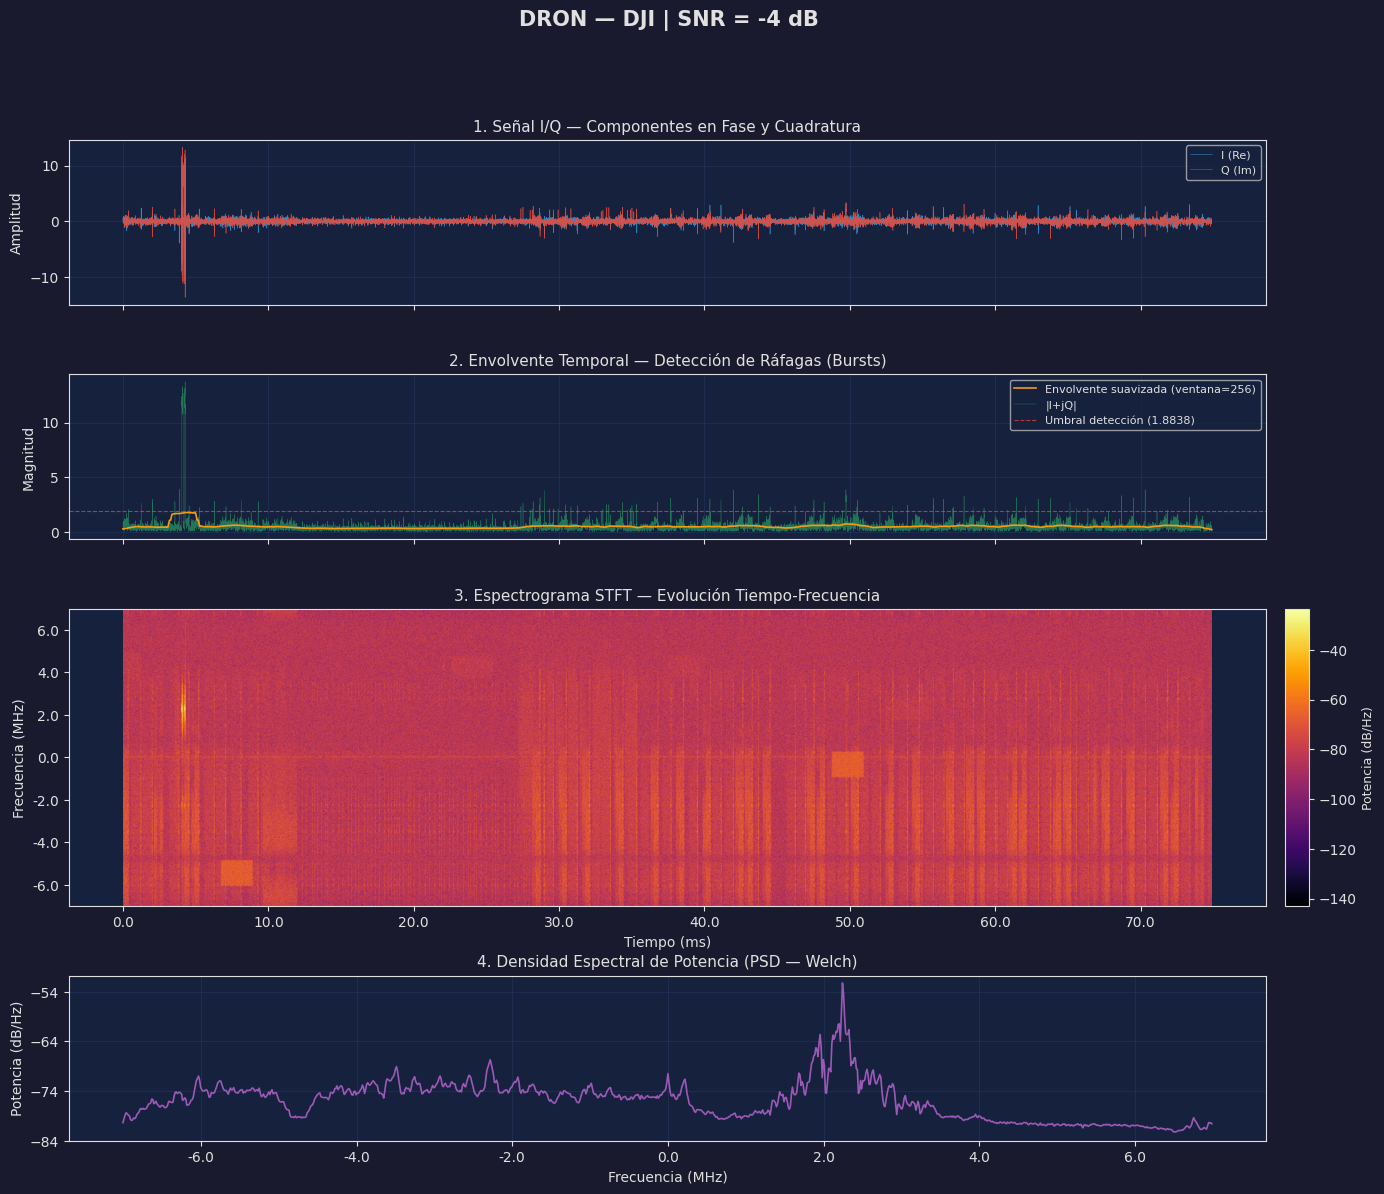

In [6]:
fig = panel_completo(tensor_dron, 0, -4)
plt.show()

c:\repos\DroneDetectionRF\NoisyUAV\funciones\visualizacion.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


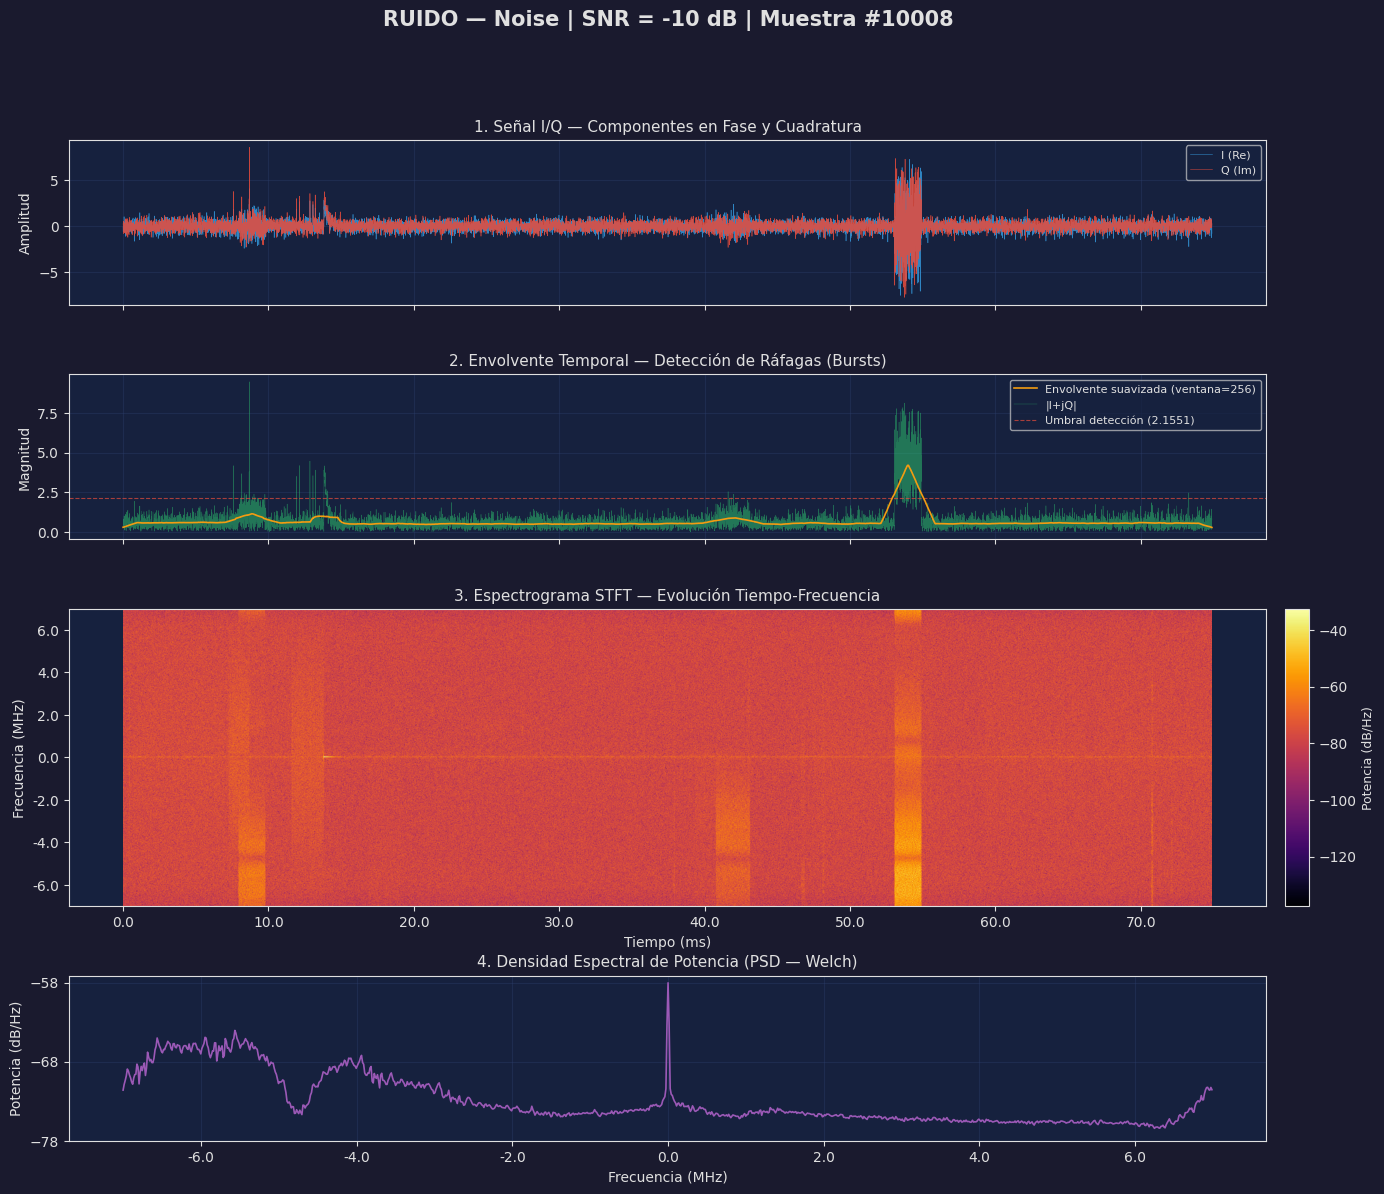

In [7]:
iq_noise, sid_noise, tgt_noise, snr_noise = obtener_una_muestra(target=TARGET_NOISE, snr=-10)
fig = panel_completo(iq_noise, tgt_noise, snr_noise, sample_id=sid_noise)
plt.show()

## 5. Comparación por SNR

¿Cómo se degrada la señal de un mismo dron a medida que baja el SNR?

Esto es clave para entender el **reto de detección a SNR negativos**.

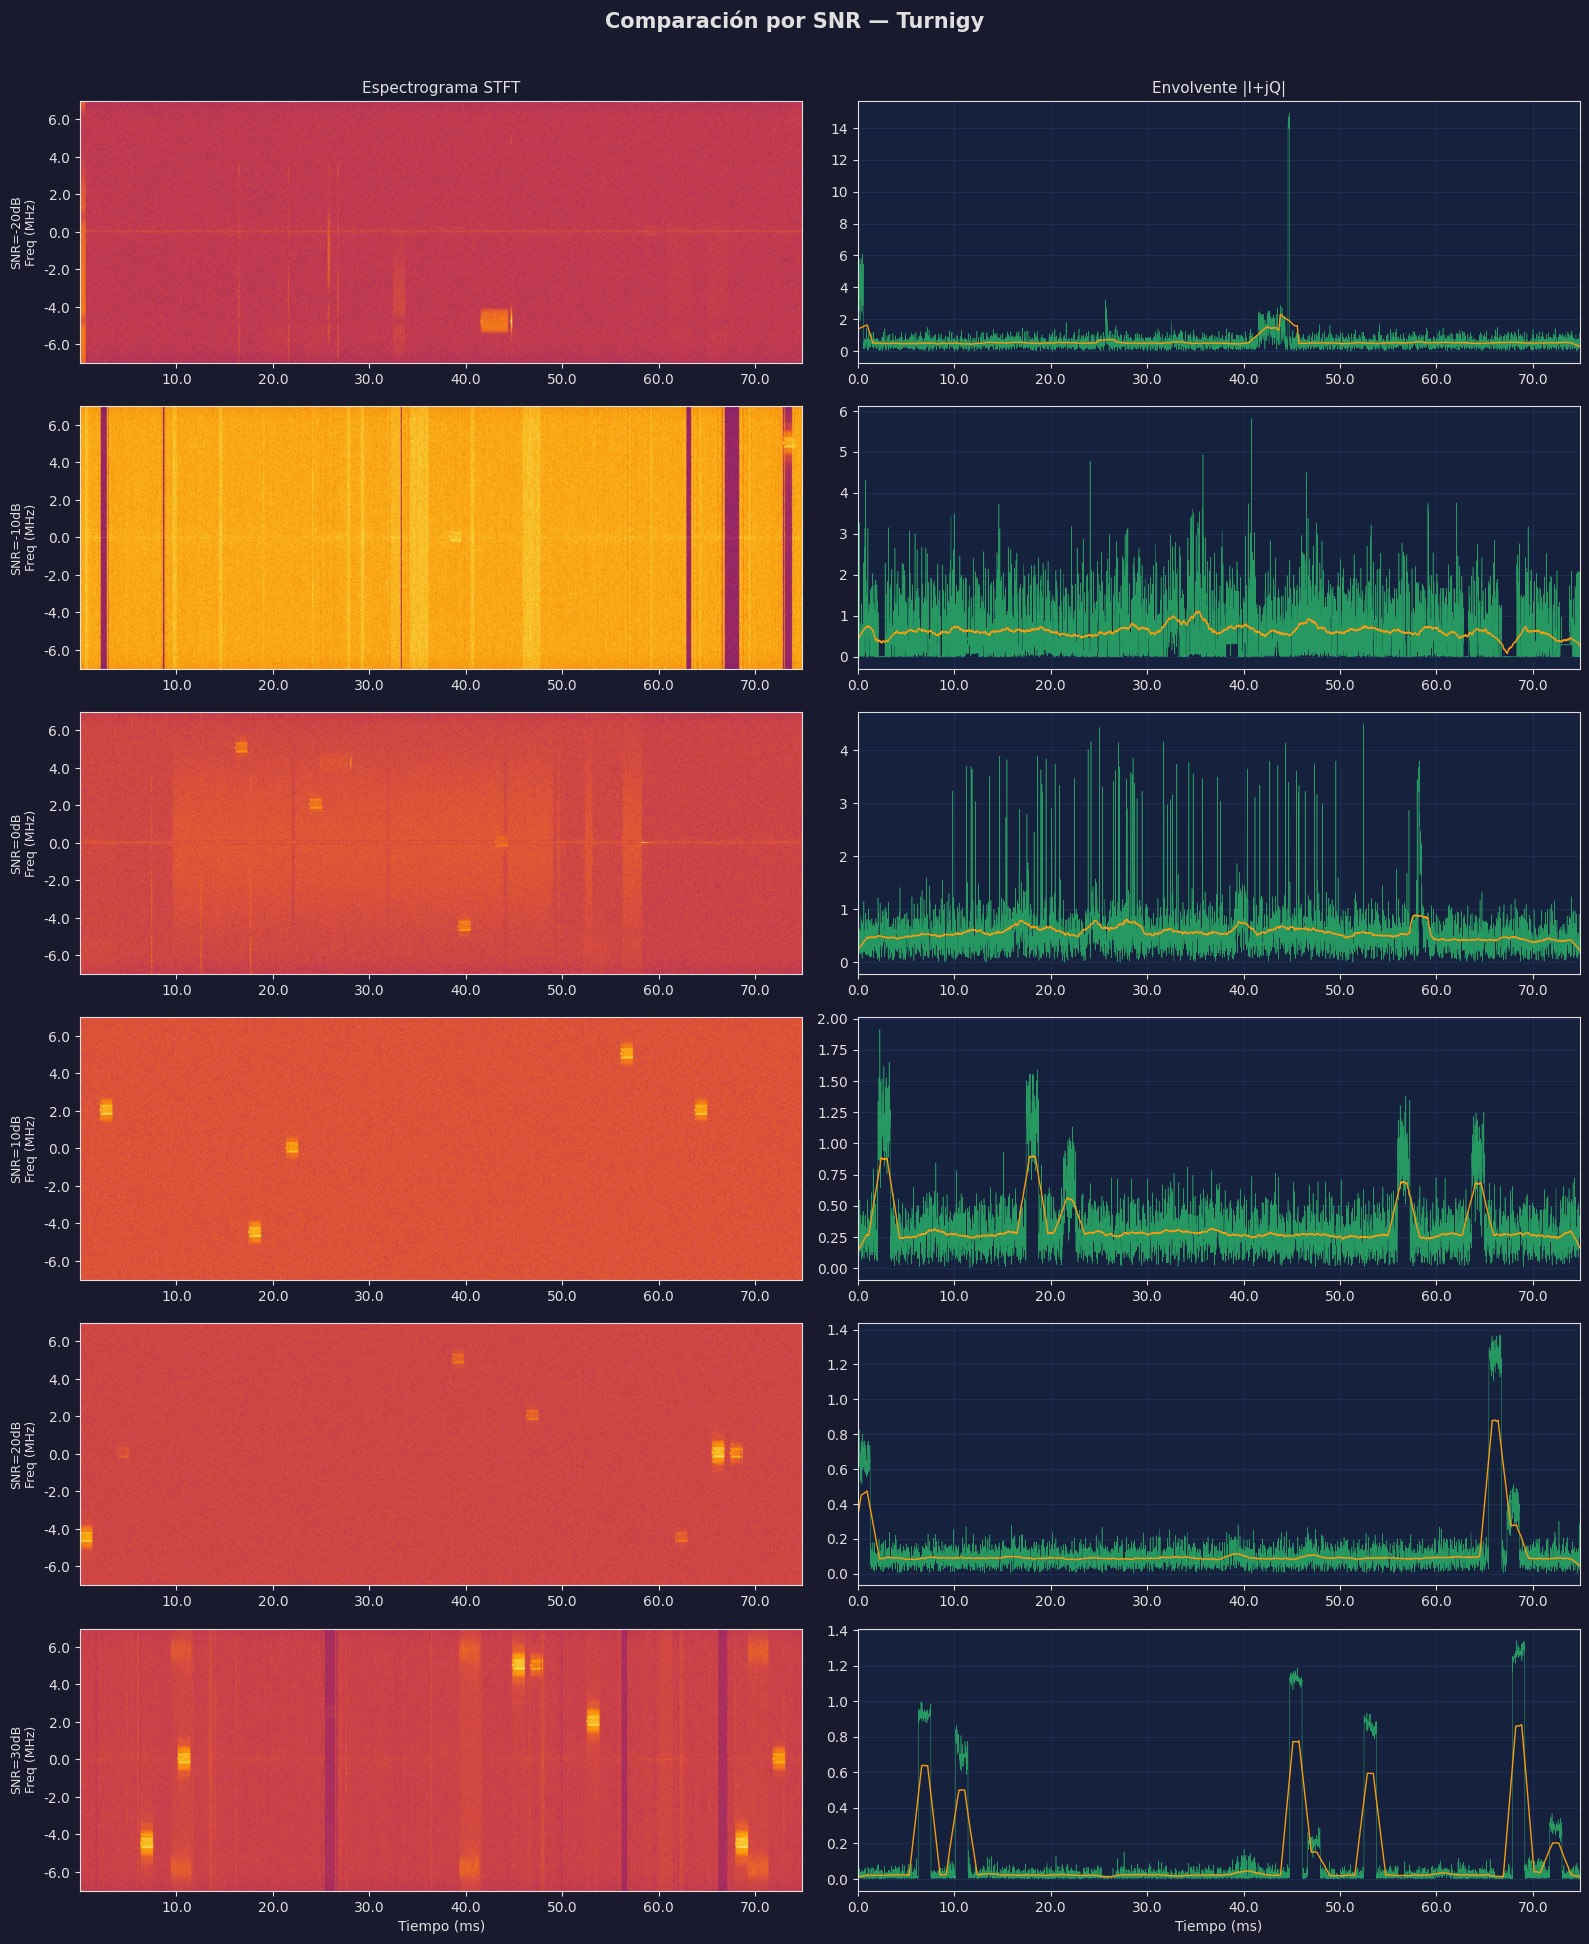

In [8]:
fig = comparar_snr(
    target=6,  # Taranis (índice 5 en orden alfabético)
    snr_list=[-20, -10, 0, 10, 20, 30],
)
plt.show()

## 6. Comparación por Clase

¿Cómo se ven las distintas firmas RF de cada dron al mismo SNR?

Cada dron tiene un patrón de **frequency hopping** y una **modulación** característica.

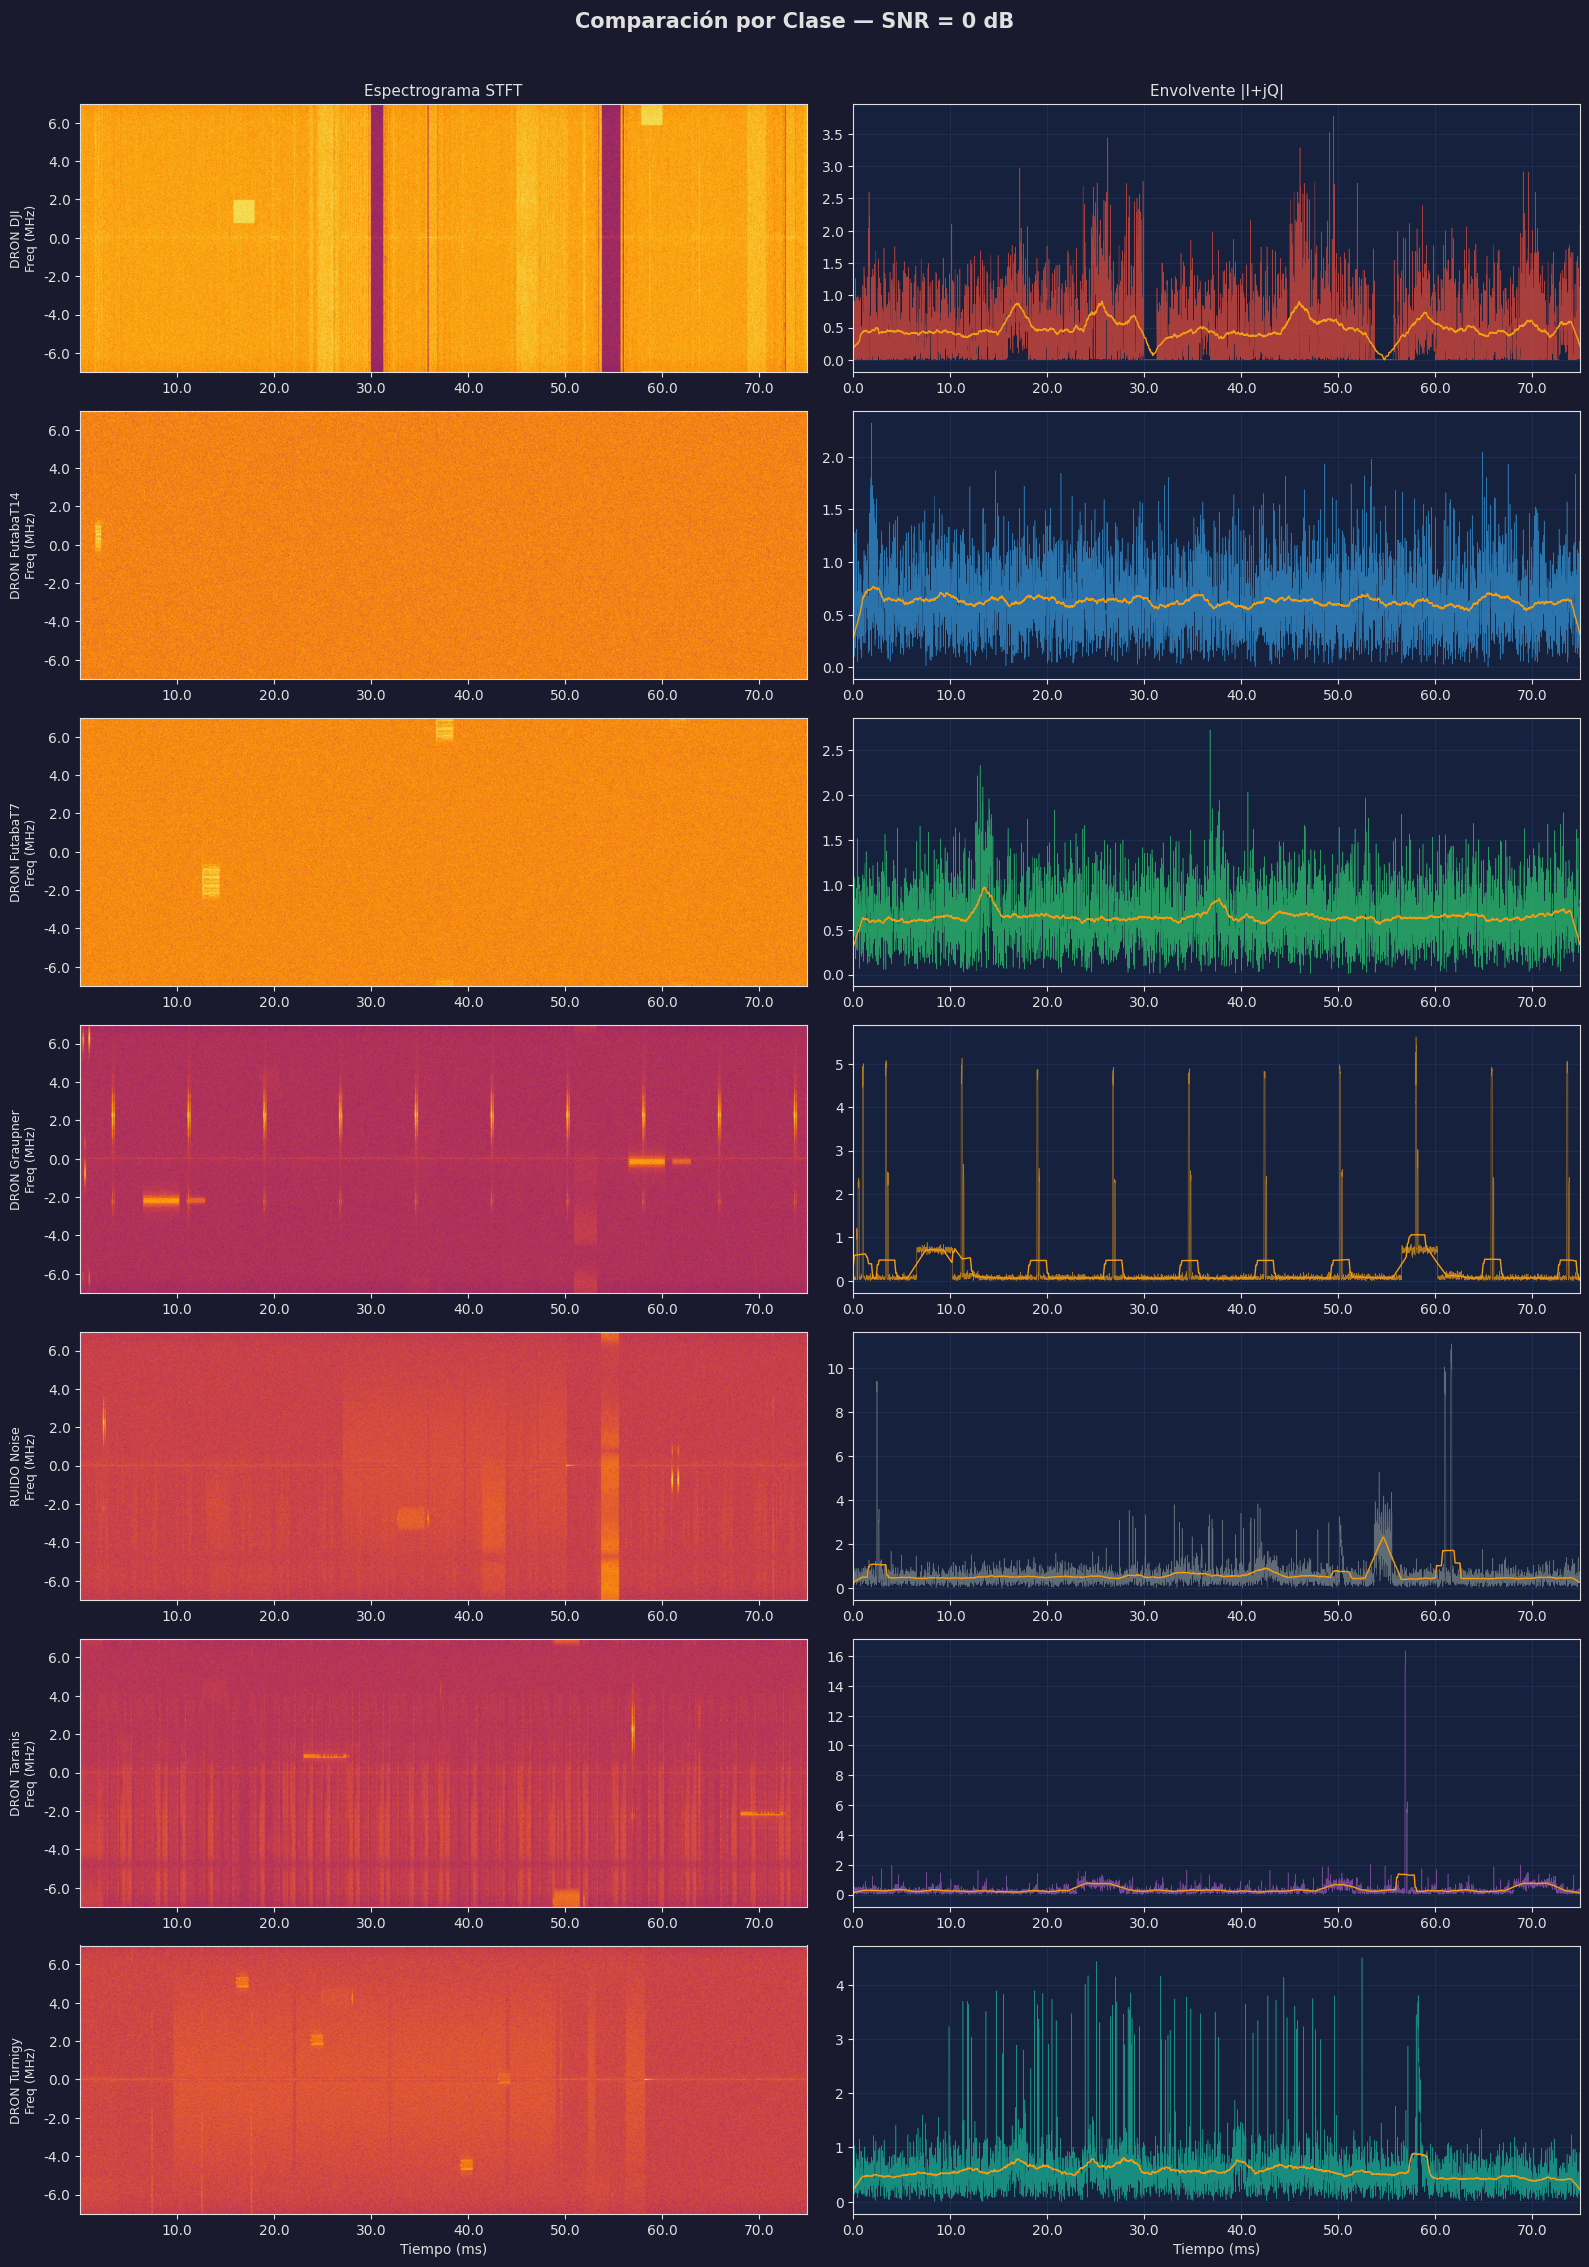

In [9]:
fig = comparar_clases(
    snr=0,
    targets=[0, 1, 2, 3, 4, 5, 6],  # Todas las clases (4=Noise)
)
plt.show()